In [1]:
import xarray as xr
import matplotlib.pyplot as plt
ds = xr.open_dataset('../data/e5-t2-201008.grib', engine='cfgrib')




/home/repiece/Projects/TCC/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Ignoring index file '../data/e5-t2-201008.grib.5b7b6.idx' older than GRIB file


In [2]:
with open('info.txt', 'w') as f:
    ...
var = ds['surface']
print(var.isnull().sum())


<xarray.DataArray 'surface' ()> Size: 8B
array(0)
Coordinates:
    number   int64 8B ...
    step     timedelta64[ns] 8B ...
    surface  float64 8B 0.0
Attributes:
    long_name:  original GRIB coordinate for key: level(surface)
    units:      1


In [3]:
print(ds)

<xarray.Dataset> Size: 129MB
Dimensions:     (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 248B 2010-08-01T12:00:00 ... 2010-08-31...
    valid_time  (time) datetime64[ns] 248B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B 0.0
Data variables:
    t2m         (time, latitude, longitude) float32 129MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-25T18:13 GRIB to CDM+CF via cfgrib-0.9.1...


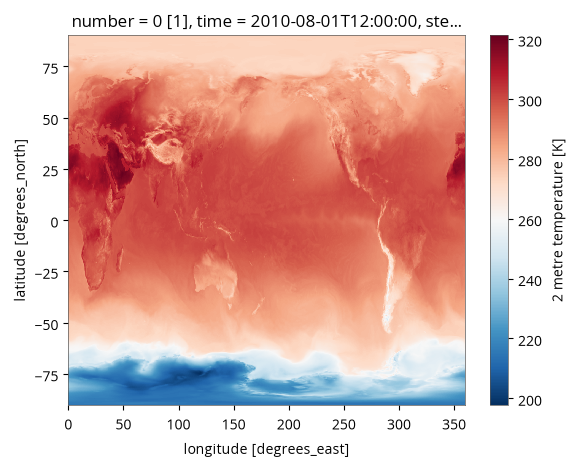

In [4]:
import matplotlib.pyplot as plt

ds['t2m'].isel(time=0).plot(cmap='RdBu_r') #type: ignore
plt.show()

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

region = ds['t2m'].sel(
    latitude=slice(34, 28),
    longitude=slice(110, 122)
)
temp = region.sel(time='2010-08-10T12:00:00')
temp = temp-273.15

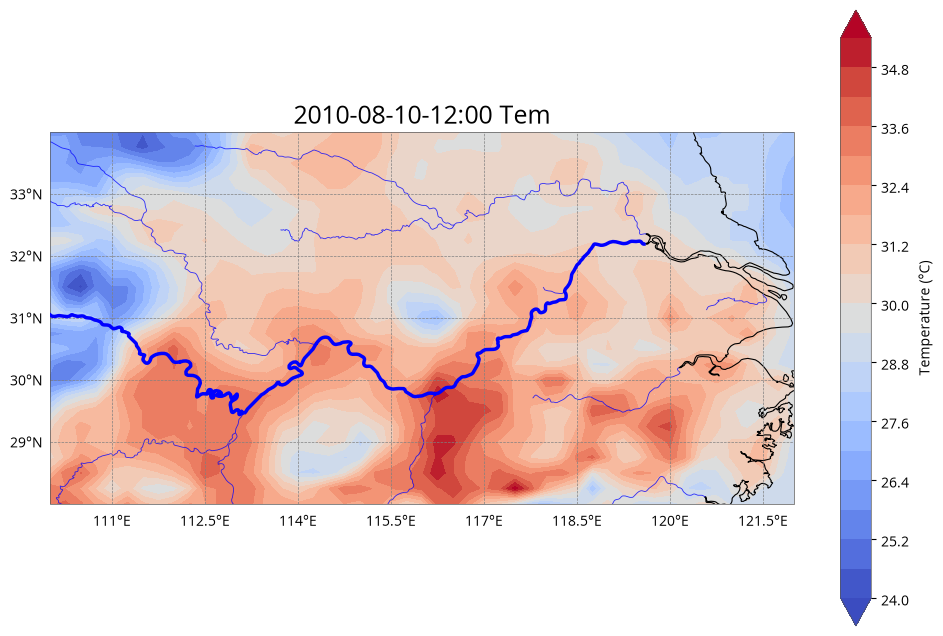

In [6]:
from cartopy.io import shapereader
from cartopy.feature import ShapelyFeature

river_path = shapereader.natural_earth(
    resolution='10m',
    category='physical',
    name='rivers_lake_centerlines'
)
reader = shapereader.Reader(river_path)

yangtze_geoms = []
for record in reader.records():
    name = record.attributes.get('name', '')
    if 'Yangtze' in name or 'Chang Jiang' in name or 'Changjiang' in name:
        yangtze_geoms.append(record.geometry)

yangtze_feature = ShapelyFeature(
    yangtze_geoms,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='blue',
    linewidth=2.5,
    linestyle='-',
    alpha=1.0
)


fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())


ax.set_extent([110, 122, 28, 34], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.6, alpha=0.8, zorder=2)
ax.add_feature(yangtze_feature, zorder=5)

cf = ax.contourf(
    temp.longitude, temp.latitude, temp,
    levels=20,
    cmap="coolwarm",
    transform=ccrs.PlateCarree(),
    extend="both"
)

cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.05, shrink=0.8)
cbar.set_label("Temperature (°C)")

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False
ax.set_title('2010-08-10-12:00 Tem', fontsize=18)
plt.tight_layout()
plt.savefig("temperature_map.png", dpi=300)
plt.show()

In [7]:
ti_region = ds['t2m'].sel(
    latitude=31,
    longitude=120,
    method='nearest'
)
ti_region-=273.15

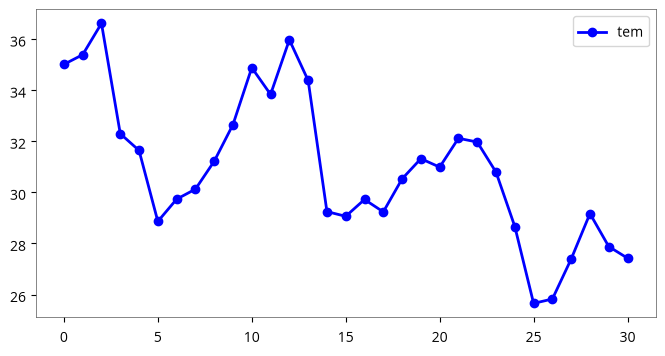

In [8]:
x = np.array(range(31))
plt.figure(figsize=(8,4))
plt.plot(x, ti_region, marker='o', color='blue', linewidth=2, label='tem')
#plt.bar(x, ti_region)
plt.legend()
plt.show()
